## Reading dataset


Lets read Iris datset. Iris has 3 target classes.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Step 1: Load and preprocess the Iris dataset
df = sns.load_dataset('iris')

print(df.head(5))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

print(le.classes_)
print(df.head())

['setosa' 'versicolor' 'virginica']
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [5]:
print(df.shape)

(150, 5)


In [6]:
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width     species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    1.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    0.000000
25%        5.100000     2.800000      1.600000     0.300000    0.000000
50%        5.800000     3.000000      4.350000     1.300000    1.000000
75%        6.400000     3.300000      5.100000     1.800000    2.000000
max        7.900000     4.400000      6.900000     2.500000    2.000000


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None


In [8]:
# Assuming that preprocessing , etc is done

In [9]:
X = df.iloc[:, :-1]  # All rows, all columns except last. This is the feature
y = df.iloc[:, -1]   # All rows, only the last column. This is the target/response variable

In [10]:
print(X.shape)
# print("###############")
# print(X)

(150, 4)


In [11]:
# Lets see how many classes does y has
print(y.unique())

[0 1 2]


In [12]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"First 5 training data:\n {X_train[:5]}")

First 5 training data:
     sepal_length  sepal_width  petal_length  petal_width
22           4.6          3.6           1.0          0.2
15           5.7          4.4           1.5          0.4
65           6.7          3.1           4.4          1.4
11           4.8          3.4           1.6          0.2
42           4.4          3.2           1.3          0.2


In [13]:
print(X_train.shape) # rows,columns
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(120, 4)
(120,)
(30, 4)
(30,)


In [14]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"(After standardizing)First 5 training data:\n {X_train[:5]}")

# Convert target labels to one-hot encoding (optional for sparse_categorical_crossentropy)
y_train_onehot = to_categorical(y_train, num_classes=3) # iris target has 3 classes.
y_test_onehot = to_categorical(y_test, num_classes=3)
print(f"First 6 training labels y_train[:6]:\n {y_train[:6]}")
print(f"First 6 onehot training labels y_train_onehot[:6]:\n {y_train_onehot[:6]}")


(After standardizing)First 5 training data:
 [[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]
First 6 training labels y_train[:6]:
 22     0
15     0
65     1
11     0
42     0
146    2
Name: species, dtype: int32
First 6 onehot training labels y_train_onehot[:6]:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [15]:
# 112/8 = 14 is the batch size
#  Create a simple sequential model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),  # Input layer (4 features). The hidden layer has 64 neuron
    layers.Dense(3, activation='softmax')  # Output layer (3 classes)
])

model.summary()

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

## 1 First Dense Layer (Hidden Layer)
- Input Shape: (4,) (4 input features)
- Units (Neurons): 64
- Weights Calculation:
  
  (Input Features×Neurons)+Bias

  (4×64)+64=256+64=320

## 2️. Second Dense Layer (Output Layer)
- Input Shape: (64,) (from the previous layer)
- Units (Neurons): 3 (for 3-class classification)
- Weights Calculation:

  (Input Features×Neurons)+Bias

  (64×3)+3=192+3=195

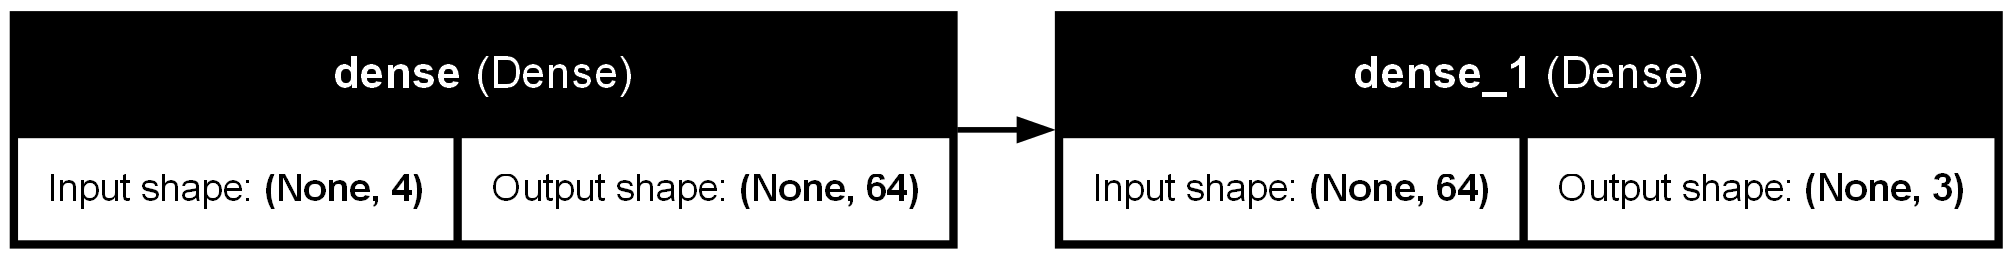

In [16]:
# Lets visualize
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # TB Top to Bottom (vertical)
)


In [52]:
#  Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#  Train the model
model.fit(X_train, y_train_onehot, epochs=10, batch_size=8, validation_split=0.1)  # Train for 10 epochs

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6944 - loss: 0.9030 - val_accuracy: 0.5833 - val_loss: 0.9275
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6944 - loss: 0.7639 - val_accuracy: 0.5833 - val_loss: 0.8337
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7130 - loss: 0.6590 - val_accuracy: 0.5000 - val_loss: 0.7647
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5860 - val_accuracy: 0.5833 - val_loss: 0.7119
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8056 - loss: 0.5320 - val_accuracy: 0.6667 - val_loss: 0.6703
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.4901 - val_accuracy: 0.6667 - val_loss: 0.6363
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8426 - loss: 0.4589 - val_accuracy: 0.6667 - val_loss: 0.6070
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8426 - loss: 0.4313 - val_accuracy: 0.7500 - val_loss

In [25]:
# Step 5: Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_onehot)
print(f"Test accuracy: {test_acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9000 - loss: 0.4101
Test accuracy: 0.90


90%...pretty good 

In [40]:
#  Make predictions on 1 sample

sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Convert list to NumPy array
predictions = model.predict(sample)  # Predict on the sample 
predicted_labels = predictions.argmax(axis=1)  # Get the predicted class

print(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[2]


In [41]:
#  Make predictions on all samples
samples = -1 # -1 to read all samples
predictions = model.predict(X_test[:samples])  # Predict on the first few samples of the test set
predicted_labels = predictions.argmax(axis=1)  # Get the predicted class
true_labels = y_test[:samples]  # Get actual labels

# Create a DataFrame for side-by-side comparison
df_results = pd.DataFrame({"Predicted": predicted_labels,
                           "Actual": true_labels})

print(df_results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
     Predicted  Actual
73           1       1
18           0       0
117          2       2
78           2       1
76           2       1
31           0       0
64           1       1
140          2       2
68           1       1
82           1       1
109          2       2
12           0       0
36           0       0
9            0       0
19           0       0
56           2       1
136          2       2
69           1       1
55           1       1
131          2       2
29           0       0
123          2       2
26           0       0
127          2       2
128          2       2
145          2       2
110          2       2
101          2       2
45           0       0


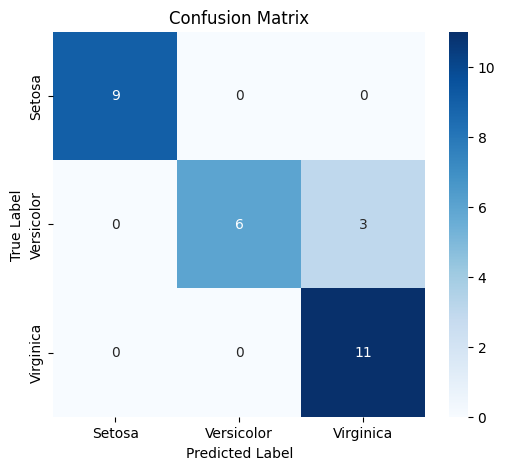

In [42]:
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Setosa", "Versicolor", "Virginica"],
            yticklabels=["Setosa", "Versicolor", "Virginica"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

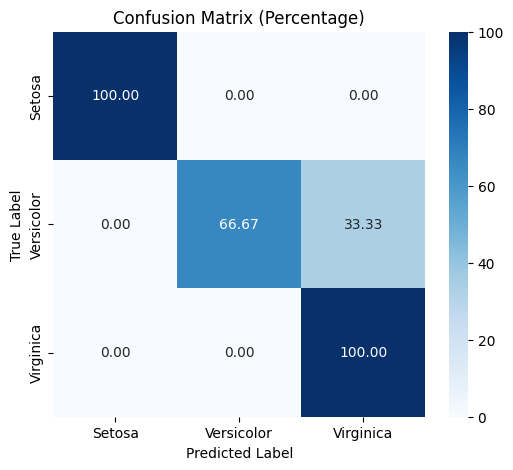

In [43]:
# Convert to percentage
cm_percentage = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  # Normalize each row

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap='Blues', xticklabels=["Setosa", "Versicolor", "Virginica"],
            yticklabels=["Setosa", "Versicolor", "Virginica"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()

In [44]:
# Save the model
model.save("model.keras")

In [45]:
# Load the model back if you need in future
loaded_model = tf.keras.models.load_model("model.keras")

In [47]:
# Use loaded model

sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Convert list to NumPy array
predictions = loaded_model.predict(sample)  # Predict on the sample 
predicted_labels = predictions.argmax(axis=1)  # Get the predicted class

print(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
[2]
